Anonymous DataSet.<br>
The underlying phenomenon and data quality are unknown.<br>
Binary target 'Y' is to be predicted.<br><br>
Data source:<br>
URL: https://www.kaggle.com/datasets/alimohammedbakhiet/anonymous-data<br>

## Contents
1. **Data overview** <br> _Outlook on raw data._
2. **Data wrangling** <br> _Data Cleaning<br>Train/test split<br>Statistical interference<br>Correlations<br>_
3. **Machine learning with sklearn** <br> _ML setup<br>Training<br>Training performance<br>Prediction performance<br>Best ML model_
4. **xgboost.XGBClassifier** <br> _Training<br>Prediction performance_
5. **Models comparison** <br> _Accuracy and AUC (area under the curve) are adopted._

## 0. Dependencies

In [1]:
import time

# Linear algebra and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import KBinsDiscretizer

# Statistical interference
import scipy.stats
from scipy import stats
from scipy.stats import pointbiserialr

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Pipelining
from sklearn.pipeline import make_pipeline

# metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

# 1) Data overwiev

In [2]:
df = pd.read_csv('/home/petewojtczak/datasets_csv/or_data.csv')
df.sample(7)

,YEAR,Y,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,R15,R16
784,2018,0,1.144,1.144,1.034,0.997,0.181,0.181,1.442,0.201,1.0,0.128,0.128,0.147,-0.648,-0.117,-0.916,-0.117
1018,2016,1,3.433,3.433,1.246,0.824,1.287,1.562,2.204,4.305,1.0,0.049,0.049,0.203,0.013,0.017,0.348,0.017
536,2018,1,1.158,1.235,0.106,0.547,0.321,0.588,3.085,6.838,1.0,0.073,0.073,0.165,0.195,0.063,0.858,0.063
284,2014,1,0.283,1.177,0.153,0.885,0.154,0.174,1.158,1.340,1.0,0.248,0.248,0.330,0.052,0.008,0.032,0.008
686,2012,1,0.466,2.030,0.239,0.679,1.588,2.340,4.611,19.908,1.0,0.107,0.107,0.320,0.051,0.081,0.756,0.081
907,2015,1,1.051,1.405,0.263,0.872,0.309,0.354,1.227,1.890,1.0,0.380,0.380,0.612,0.211,0.065,0.172,0.065
742,2012,0,0.643,1.275,0.498,0.538,0.316,0.587,2.722,1.503,1.0,0.512,0.512,1.212,-0.248,-0.078,-0.153,-0.078


In [3]:
df.shape

(1120, 18)

In [4]:
df.isnull().values.any()

False

In [5]:
feature_info = {
    'feature': [],
    'dtype': [],
    'unique_val': [],
    }

for col in df.columns:
    feature_info['feature'].append(col)
    feature_info['dtype'].append(df[col].dtype)
    feature_info['unique_val'].append(len(df[col].unique()))
    
features = pd.DataFrame(feature_info)
features.set_index('feature', inplace=True)
features = features.sort_values(by='unique_val', ascending=False)

In [6]:
features.T

feature,R8,R7,R2,R1,R6,R15,R12,R5,R4,R3,R13,R11,R10,R14,R16,R9,YEAR,Y
dtype,object,object,object,object,float64,object,object,float64,float64,float64,object,float64,float64,float64,float64,float64,int64,int64
unique_val,821,807,789,752,701,687,641,627,570,529,505,476,473,364,360,66,8,2


In [7]:
df.sample(3)

,YEAR,Y,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,R15,R16
573,2013,0,0.430,1.133,0.045,0.982,0.714,0.727,6.178,18.418,1.0,0.017,0.017,0.020,0.074,0.053,3.054,0.053
321,2017,1,4.362,3.255,0.281,0.856,0.430,0.502,0.725,5.821,1.0,0.004,0.004,0.015,0.113,0.048,12.161,0.048
192,2018,1,0.624,1.417,0.283,0.501,0.220,0.439,1.492,2.198,1.0,0.293,0.293,0.827,0.032,0.007,0.024,0.007


We will need to move twoards numeric dtypes with all features.

In [8]:
df['Y'].value_counts(normalize=True)

1    0.642857
0    0.357143
Name: Y, dtype: float64

In [9]:
df['R9'].value_counts(normalize=True)

 1.000    0.904464
-1.000    0.012500
 0.000    0.008929
 0.647    0.003571
 0.536    0.003571
            ...   
 4.598    0.000893
 7.227    0.000893
 0.921    0.000893
 1.076    0.000893
 1.150    0.000893
Name: R9, Length: 66, dtype: float64

# 2) Data wrangling

## 2.1) Data Cleaning

In [10]:
df.shape

(1120, 18)

In [11]:
# invariant feature
df = df.drop('R9', axis=1)
features = features.loc[features.index != 'R9']

# dtypes conversion
for col in df.columns:
    if df[col].dtype == object:
        df = df[~(df[col].str.contains(','))]
        df[col] = df[col].astype('float')
features.dtype = 'float64'
features.loc['Y','dtype'] = 'int64'
features.loc['YEAR','dtype'] = 'int64'

# zero-only rows exclusion
excluded_from_zero_check_columns = ['YEAR', 'Y']
mask = ~(df.drop(columns=excluded_from_zero_check_columns) == 0).all(axis=1)
df = df[mask]

# duplicates removal
df.drop_duplicates(inplace=True)

In [12]:
df.Y.value_counts(normalize=True)

1    0.671982
0    0.328018
Name: Y, dtype: float64

In [13]:
df.shape

(878, 17)

## 2.2) Train/test split

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 878 entries, 0 to 1117
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    878 non-null    int64  
 1   Y       878 non-null    int64  
 2   R1      878 non-null    float64
 3   R2      878 non-null    float64
 4   R3      878 non-null    float64
 5   R4      878 non-null    float64
 6   R5      878 non-null    float64
 7   R6      878 non-null    float64
 8   R7      878 non-null    float64
 9   R8      878 non-null    float64
 10  R10     878 non-null    float64
 11  R11     878 non-null    float64
 12  R12     878 non-null    float64
 13  R13     878 non-null    float64
 14  R14     878 non-null    float64
 15  R15     878 non-null    float64
 16  R16     878 non-null    float64
dtypes: float64(15), int64(2)
memory usage: 123.5 KB


In [15]:
y = df['Y']
X = df.drop('Y', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=df['Y'])

In [16]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((702, 16), (702,), (176, 16), (176,))

In [17]:
# the target is stratified 
y_test.value_counts(normalize=True)

1    0.670455
0    0.329545
Name: Y, dtype: float64

## 2.3) Statistical interference

In [18]:
X_train.shape

(702, 16)

In [19]:
# ordinal feature 'YEAR' is found to be insignificant
if scipy.stats.spearmanr(y_train, X_train['YEAR'])[1] > 0.05:
    X_train = X_train.drop('YEAR', axis=1)
    X_test = X_test.drop('YEAR', axis=1)
    features = features.loc[features.index != 'YEAR']

In [20]:
# Only continous features are left
features.T

feature,R8,R7,R2,R1,R6,R15,R12,R5,R4,R3,R13,R11,R10,R14,R16,Y
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
unique_val,821,807,789,752,701,687,641,627,570,529,505,476,473,364,360,2


In [21]:
X_train.sample(3)

,R1,R2,R3,R4,R5,R6,R7,R8,R10,R11,R12,R13,R14,R15,R16
928,1.056,1.861,0.619,0.151,0.176,1.165,2.519,3.503,0.791,0.791,9.735,-0.273,-0.048,-0.061,-0.048
1044,0.289,0.339,0.145,0.107,0.042,0.396,-0.203,0.928,0.388,0.388,1.237,0.163,0.007,0.018,0.007
989,0.876,0.927,0.001,0.727,0.262,0.361,-4.555,273.997,0.010,0.010,0.013,-0.025,-0.007,-0.650,-0.007


In [22]:
# continous features vs binary target (significance testing)
for feature in X_train.columns:
    # features found to be insignificant are excluded
    if pointbiserialr(X_train[feature], y_train)[1] > 0.05:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)

In [23]:
X_train.shape

(702, 7)

## 2.4) Correlations

In [24]:
df_train = pd.concat([X_train, y_train], axis=1)

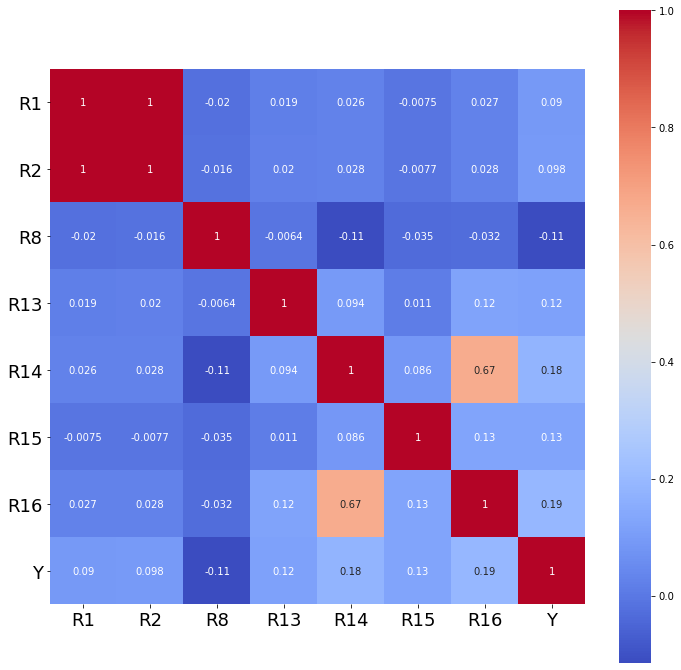

In [25]:
# Pearson coeff heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(df_train.corr(), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=18, rotation=0)
plt.tick_params(axis='y', labelsize=18, rotation=0)
plt.show()

In [26]:
scipy.stats.pointbiserialr(y_train, X_train['R1'])[1], scipy.stats.pearsonr(y_train, X_train['R2'])[1]

(0.0167405352001698, 0.009500450239290024)

In [27]:
scipy.stats.pearsonr(y_train, X_train['R2'])[1]

0.009500450239290024

In [28]:
X_train = X_train.drop('R1', axis=1)
X_test = X_test.drop('R1', axis=1)

# 3) Machine Learning with sklearn

Following classifiers are GridSearched in effort to find the best suited model:
1. LogisticRegression
2. RandomForestClassifier
3. KNeighborsClassifier
4. GradientBoostingClassifier

## 3.1) ML setup

In [29]:
prep = make_column_transformer((KBinsDiscretizer(n_bins=10, encode='ordinal'), X_train.columns))

pipelines = {
    'logreg':make_pipeline(prep, LogisticRegression(random_state=0)),
    'forest':make_pipeline(prep, RandomForestClassifier(random_state=0)),
    'knn':make_pipeline(prep, KNeighborsClassifier()),
    'gbc':make_pipeline(prep, GradientBoostingClassifier(random_state=0))   
    }

hypergrid = {
    'logreg': {
        'logisticregression__C':[1.4, 2, 2.6, 4, 5.7, 7.8],
        'logisticregression__solver':['lbfgs', 'liblinear']
    },
    'forest': {
        'randomforestclassifier__n_estimators':[8, 20, 22, 24, 46, 52],
        'randomforestclassifier__criterion':['gini', 'entropy'],
        'randomforestclassifier__min_samples_leaf':[1, 4, 8]
    },
    'knn': {
        'kneighborsclassifier__n_neighbors':list(range(160, 220, 5)),
        'kneighborsclassifier__weights':['uniform', 'distance']
    },
    'gbc': {
        'gradientboostingclassifier__learning_rate':[0.02, 0.075, 0.1, 0.15, 0.25],
        'gradientboostingclassifier__n_estimators':[24, 30, 60, 90, 120],
        'gradientboostingclassifier__loss':['exponential', 'deviance']
    }
    }

## 3.2) Training

In [30]:
%%time
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

models_acc = {}
models_auc = {}
for algo, pipeline in pipelines.items():
    model_acc = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='accuracy')
    model_auc = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='roc_auc')
    model_acc.fit(X_train,y_train)
    model_auc.fit(X_train,y_train)
    models_acc[algo] = model_acc
    models_auc[algo] = model_auc

CPU times: user 1min 25s, sys: 84.5 ms, total: 1min 25s
Wall time: 1min 25s


## 3.3) Training performance

In [31]:
train_results = pd.DataFrame(columns=['ACC', 'AUC'])

for algo in models_acc.keys():
    train_results.loc[algo] = [round(models_acc[algo].best_score_, 3), round(models_auc[algo].best_score_, 3)]
    
train_results.sort_values(by='AUC', ascending=False)

,ACC,AUC
gbc,0.882,0.909
forest,0.880,0.907
knn,0.872,0.894
logreg,0.869,0.880


## 3.4) Prediction performance

In [32]:
test_results = pd.DataFrame(columns=['ACC', 'AUC'])

for algo in models_acc.keys():
    y_pred_acc = models_acc[algo].predict(X_test)
    y_pred_auc = models_auc[algo].predict(X_test)
    test_results.loc[algo] = [round(accuracy_score(y_test, y_pred_acc), 3), round(roc_auc_score(y_test, y_pred_auc), 3)]

test_results.sort_values(by='AUC', ascending=False)

,ACC,AUC
knn,0.909,0.901
logreg,0.898,0.893
gbc,0.898,0.884
forest,0.915,0.872


In [33]:
y_pred = models_auc['knn'].predict(X_test)
confusion = confusion_matrix(y_test, y_pred)

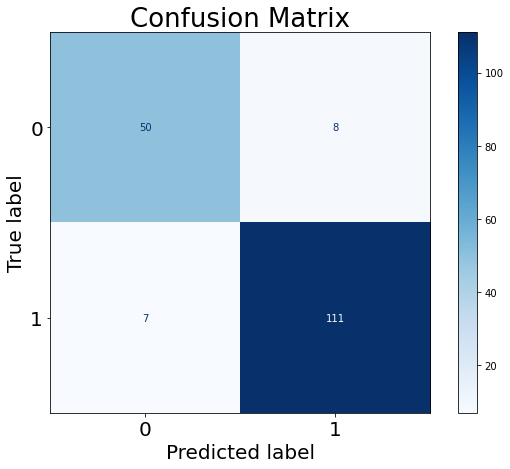

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_confusion_matrix(models_auc['knn'], X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_xlabel('Predicted label', fontsize=20)
ax.set_ylabel('True label', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.title('Confusion Matrix', fontsize=26)
plt.figsize=(16, 7)
plt.show()

In [35]:
TP = confusion[1,1]
TN = confusion[0,0]
FP = confusion[0,1]
FN = confusion[1,0]

print('Sensitivity')
print('When the acutal value is positive, how often is the prediction correct?')
print('sensitivity: {}\n'.format(round(TP/float(TP + FN), 4)))
print('Specificity')
print('When the acutal value is negative, how often is the prediction correct?')
print('specificity: {}'.format(round(TN/float(TN + FP), 4)))

Sensitivity
When the acutal value is positive, how often is the prediction correct?
sensitivity: 0.9407

Specificity
When the acutal value is negative, how often is the prediction correct?
specificity: 0.8621


## 3.5) Best ML model

In [36]:
models_auc['knn'].best_params_

{'kneighborsclassifier__n_neighbors': 170,
 'kneighborsclassifier__weights': 'distance'}

In [37]:
models_auc['knn']

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('kbinsdiscretizer',
                                                                         KBinsDiscretizer(encode='ordinal',
                                                                                          n_bins=10),
                                                                         Index(['R2', 'R8', 'R13', 'R14', 'R15', 'R16'], dtype='object'))])),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier())]),
             param_grid={'kneighborsclassifier__n_neighbors': [160, 165, 170,
                                                               175, 180, 185,
                                                               190, 195, 200,
                                                               205, 210, 215],
                         'kneighborsclassifier__weights': ['uniform',
                                                           'distance']},
             scoring='roc_auc')

# 4) xgboost.XGBClassifier

## 4.1) Training

In [38]:
%%time
# preprocessing
prep = make_column_transformer((KBinsDiscretizer(n_bins=10, encode='ordinal'), X_train.columns))
X_train_transformed = prep.fit_transform(X_train)

# xgboost hyperspace
params={
 "learning_rate"    : [0.001, 0.01, 0.10] ,
 "max_depth"        : [ 3, 6, 12],
 "colsample_bytree" : [ 0.1, 0.3]
}

# clasifier instantiation
clf = xgboost.XGBClassifier()

# training
gs = GridSearchCV(clf, param_grid=params, scoring='roc_auc', cv=5)
gs.fit(X_train_transformed,y_train)

CPU times: user 2min 8s, sys: 1.23 s, total: 2min 10s
Wall time: 23.5 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_ca...one,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, reg_alpha=None,
                                     reg_lambda=None, ...),
             param_grid={'colsample_bytree': [0.1, 0.3],
                         'learning_rate': [0.001, 0.01, 0.1],
                         'max_depth': [3, 6, 12]},
             scoring='roc_auc')

## 4.2) Prediction performance

In [39]:
y_pred = gs.predict(prep.fit_transform(X_test))
confusion = confusion_matrix(y_test, y_pred)
confusion

array([[ 43,  15],
       [  6, 112]])

In [40]:
test_results.loc['xgboost', 'ACC'] = round(accuracy_score(y_test, y_pred), 3)
test_results.loc['xgboost', 'AUC'] = round(roc_auc_score(y_test, y_pred), 3)
test_results.loc['xgboost']

ACC    0.881
AUC    0.845
Name: xgboost, dtype: float64

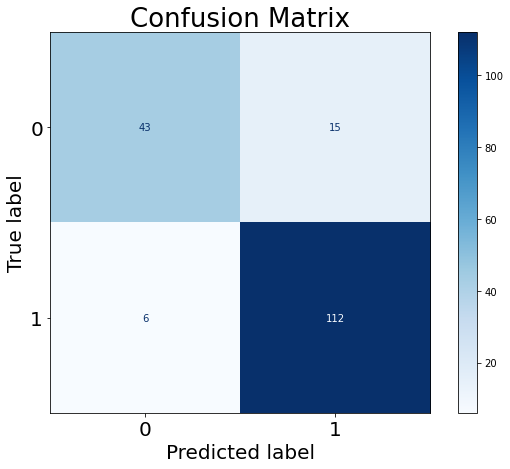

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_confusion_matrix(gs, prep.fit_transform(X_test), y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_xlabel('Predicted label', fontsize=20)
ax.set_ylabel('True label', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.title('Confusion Matrix', fontsize=26)
plt.figsize=(16, 7)
plt.show()

In [42]:
TP = confusion[1,1]
TN = confusion[0,0]
FP = confusion[0,1]
FN = confusion[1,0]

print('Sensitivity')
print('When the acutal value is positive, how often is the prediction correct?')
print('sensitivity: {}\n'.format(round(TP/float(TP + FN), 4)))
print('Specificity')
print('When the acutal value is negative, how often is the prediction correct?')
print('specificity: {}'.format(round(TN/float(TN + FP), 4)))

Sensitivity
When the acutal value is positive, how often is the prediction correct?
sensitivity: 0.9492

Specificity
When the acutal value is negative, how often is the prediction correct?
specificity: 0.7414


# 5) Models comparison

In [43]:
test_results.sort_values(by='AUC', ascending=False)

,ACC,AUC
knn,0.909,0.901
logreg,0.898,0.893
gbc,0.898,0.884
forest,0.915,0.872
xgboost,0.881,0.845
